In [1]:
#Setup

In [2]:
import os
import sys
import pandas as pd
from pathlib import Path

PROJECT_ROOT = os.path.abspath("..")
sys.path.append(PROJECT_ROOT)

from src.inference import CLIPInference
from src.aggregation import aggregate_video_scores
from src.metrics import evaluate
from src.config import ANOMALY_CLASSES, NORMAL_CLASSES

In [3]:
#Load Validation Manifest

In [4]:
val_df = pd.read_csv("../data/validation_manifest.csv")

print("Validation segments:", len(val_df))
val_df.head()

Validation segments: 119


,segment_uid,class,video_id,segment_id,num_frames,segment_path,label,split
0,validation_Arrest_Arrest003_x264_seg_0000,Arrest,Arrest003_x264,seg_0000,16,/content/drive/MyDrive/clip_delivery/validatio...,1,validation
1,validation_Arrest_Arrest003_x264_seg_0001,Arrest,Arrest003_x264,seg_0001,16,/content/drive/MyDrive/clip_delivery/validatio...,1,validation
2,validation_Arrest_Arrest003_x264_seg_0002,Arrest,Arrest003_x264,seg_0002,16,/content/drive/MyDrive/clip_delivery/validatio...,1,validation
3,validation_Arrest_Arrest003_x264_seg_0003,Arrest,Arrest003_x264,seg_0003,16,/content/drive/MyDrive/clip_delivery/validatio...,1,validation
4,validation_Arrest_Arrest003_x264_seg_0004,Arrest,Arrest003_x264,seg_0004,16,/content/drive/MyDrive/clip_delivery/validatio...,1,validation


In [5]:
#Path Fix

In [6]:
def fix_path(p):
    return p.replace(
        "/content/drive/MyDrive/clip_delivery/validation_subset",
        "../data/segments_16/validation"
    )

val_df["segment_path"] = val_df["segment_path"].apply(fix_path)

# test
for p in val_df["segment_path"].head(5):
    print(p, "->", Path(p).exists())

../data/segments_16/validation/Arrest/Arrest003_x264/seg_0000 -> True
../data/segments_16/validation/Arrest/Arrest003_x264/seg_0001 -> True
../data/segments_16/validation/Arrest/Arrest003_x264/seg_0002 -> True
../data/segments_16/validation/Arrest/Arrest003_x264/seg_0003 -> True
../data/segments_16/validation/Arrest/Arrest003_x264/seg_0004 -> True


In [7]:
#Model Init

In [8]:
model = CLIPInference()
model.set_text_prompts()

print("Model ready")

Model ready


In [9]:
#Segment-Level Inference

In [10]:
results = []

for idx, row in val_df.iterrows():
    if idx % 50 == 0:
        print("Processing segment:", idx)

    full_path = row["segment_path"]

    pred = model.predict_segment(full_path)

    results.append({
        "video_id": row["video_id"],
        "segment_uid": row["segment_uid"],
        "true_class": row["class"],
        "score": pred["score"],
        "anomaly_score": pred["anomaly_score"],
        "normal_score": pred["normal_score"],
        "anomaly_sim": pred["anomaly_sim"],
        "normal_sim": pred["normal_sim"]
    })

results_df = pd.DataFrame(results)

print("Processed segments:", len(results_df))
results_df.head()

Processing segment: 0
Processing segment: 50
Processing segment: 100
Processed segments: 119


,video_id,segment_uid,true_class,score,anomaly_score,normal_score,anomaly_sim,normal_sim
0,Arrest003_x264,validation_Arrest_Arrest003_x264_seg_0000,Arrest,0.010498,0.308350,0.297852,"[0.3032, 0.2708, 0.3062, 0.3083]","[0.2837, 0.2979, 0.295]"
1,Arrest003_x264,validation_Arrest_Arrest003_x264_seg_0001,Arrest,0.004150,0.313477,0.309326,"[0.3044, 0.2634, 0.3098, 0.3135]","[0.2878, 0.3093, 0.2952]"
2,Arrest003_x264,validation_Arrest_Arrest003_x264_seg_0002,Arrest,0.002686,0.310059,0.307373,"[0.2993, 0.2625, 0.3074, 0.31]","[0.2869, 0.3074, 0.2942]"
3,Arrest003_x264,validation_Arrest_Arrest003_x264_seg_0003,Arrest,0.004883,0.313721,0.308838,"[0.3005, 0.262, 0.3071, 0.3137]","[0.288, 0.3088, 0.2954]"
4,Arrest003_x264,validation_Arrest_Arrest003_x264_seg_0004,Arrest,0.010254,0.310791,0.300537,"[0.2988, 0.2756, 0.3088, 0.3108]","[0.2832, 0.294, 0.3005]"


In [11]:
#Video-Level Aggregation

In [12]:
video_df = aggregate_video_scores(results_df)

video_df.head()

,video_id,true_class,is_anomaly,anomaly_sim,normal_sim
0,Arrest003_x264,Arrest,True,"[0.32177734375, 0.2822265625, 0.311767578125, ...","[0.2890625, 0.3203125, 0.304443359375]"
1,Explosion001_x264,Explosion,True,"[0.28125, 0.2890625, 0.28466796875, 0.2841796875]","[0.25732421875, 0.267822265625, 0.295654296875]"
2,Explosion002_x264,Explosion,True,"[0.291259765625, 0.27587890625, 0.29541015625,...","[0.2744140625, 0.3017578125, 0.309326171875]"
3,Normal_Videos003_x264,NormalVideos,False,"[0.248291015625, 0.2305908203125, 0.2602539062...","[0.2296142578125, 0.248779296875, 0.261962890625]"
4,Normal_Videos005_x264,NormalVideos,False,"[0.283203125, 0.25341796875, 0.284912109375, 0...","[0.31494140625, 0.30029296875, 0.290283203125]"


--- LEARNED BEST THRESHOLD: -0.02686 ---


,video_id,true_class,is_anomaly,predicted_is_anomaly,predicted_text
0,Arrest003_x264,Arrest,True,True,CCTV video of a physical fight between people
1,Explosion001_x264,Explosion,True,True,CCTV video of a massive explosion and fire
2,Explosion002_x264,Explosion,True,True,CCTV video of a physical fight between people
3,Normal_Videos003_x264,NormalVideos,False,True,CCTV video of a thief stealing something and c...
4,Normal_Videos005_x264,NormalVideos,False,False,"CCTV video of a completely normal, safe street..."
5,Robbery048_x264,Robbery,True,True,CCTV video of a physical fight between people
6,Stealing002_x264,Stealing,True,True,CCTV video of a physical fight between people
7,Stealing003_x264,Stealing,True,True,CCTV video of a physical fight between people



--- METRICS ---
Accuracy: 0.8750 | F1 Score: 0.9231


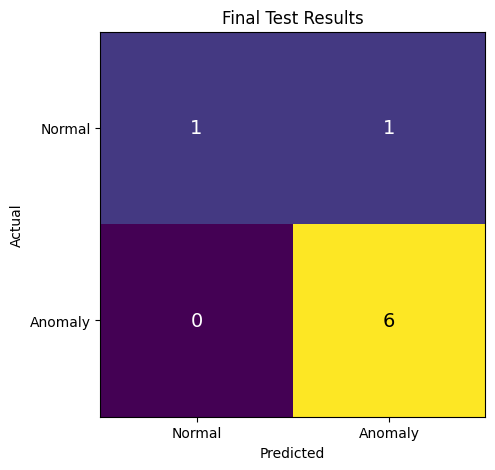

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
from IPython.display import display

video_df["score_diff"] = video_df["anomaly_sim"].apply(np.max) - video_df["normal_sim"].apply(np.max)

y_true = video_df["is_anomaly"].astype(bool)
best_threshold, best_f1 = 0, 0
thresholds = np.linspace(video_df["score_diff"].min(), video_df["score_diff"].max(), 100)

for t in thresholds:
    score = f1_score(y_true, video_df["score_diff"] > t, zero_division=0)
    if score > best_f1:
        best_f1 = score
        best_threshold = t

video_df["predicted_is_anomaly"] = video_df["score_diff"] > best_threshold

def select_final_text(row):
    if row["predicted_is_anomaly"]:
        return ANOMALY_CLASSES[np.argmax(row["anomaly_sim"])]
    else:
        return NORMAL_CLASSES[np.argmax(row["normal_sim"])]

video_df["predicted_text"] = video_df.apply(select_final_text, axis=1)

print(f"--- LEARNED BEST THRESHOLD: {best_threshold:.5f} ---")
display(video_df[["video_id", "true_class", "is_anomaly", "predicted_is_anomaly", "predicted_text"]])

y_pred = video_df["predicted_is_anomaly"].astype(bool)
print("\n--- METRICS ---")
print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f} | F1 Score: {f1_score(y_true, y_pred):.4f}")

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='viridis')
plt.xticks([0, 1], ["Normal", "Anomaly"])
plt.yticks([0, 1], ["Normal", "Anomaly"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", 
                 color="white" if cm[i, j] < cm.max()/2 else "black", fontsize=14)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Test Results")
plt.show()